# Init

In [5]:
%run ../scripts/bootstrap_notebook.py

import importlib
import sys
from copy import deepcopy
from datetime import datetime
from pathlib import Path
from pprint import pprint

import laboneq.dsl.quantum.qpu as qpu_mod
import numpy as np
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.dsl.calibration import Oscillator, SignalCalibration
from laboneq.dsl.device import DeviceSetup
from laboneq.dsl.enums import ModulationType
from laboneq.serializers import load
from laboneq.simple import *

repo_root = PROJECT_ROOT

# descriptor = generate_descriptor(
#     #pqsc=[""], # 장비 여러개 사용시
#     shfqc_6=["DEV12256"],
#     number_data_qubits=3,
#     multiplex=True,
#     number_multiplex=6,
#     include_cr_lines=False,
#     include_ef_lines=True,
#     get_zsync=False,  # Only set to True when using real device
#     save=True,
#     filename="1port",
#     ip_address="192.168.0.83",
# )

# descriptor
# setup = DeviceSetup.from_descriptor(yaml_text=descriptor, server_host="192.168.0.83")
descriptor_candidates = [
    repo_root / "configs" / "descriptors" / "1port.yaml",
    Path("../configs/descriptors/1port.yaml"),
    Path("configs/descriptors/1port.yaml"),
]
descriptor_path = next((p for p in descriptor_candidates if p.exists()), descriptor_candidates[0])
setup = DeviceSetup.from_yaml(filepath=str(descriptor_path.resolve()), server_host="192.168.0.83")
setup.instruments[0].device_options = "SHFQC/PLUS/QC6CH"

bus_ids = [f"b{i}" for i in range(3)]
bus_port = [3, 4, 5]  # used 1,2,3 for qubit drive

for i, bus in zip(bus_port, bus_ids):
    setup.add_connections(
        setup.instruments[0].uid,
        # each bus uses its own drive:
        create_connection(
            to_signal=f"{bus}/drive",
            ports=f"SGCHANNELS/{i}/OUTPUT",
        ),
        create_connection(
            to_signal=f"{bus}/drive_p",
            ports=f"SGCHANNELS/{i}/OUTPUT",
        ),
    )

# Calibrate qubit drive/measure lines for oscillator phase increments
qubit_ids = [uid for uid in setup.logical_signal_groups if uid.startswith("q")]
for qubit in qubit_ids:
    for line, frequency, mod_type in [
        ("drive", 5e9, ModulationType.HARDWARE),
        ("drive_ef", 6e9, ModulationType.HARDWARE),
        ("measure", 4e9, ModulationType.SOFTWARE),
    ]:
        logical_signal = setup.logical_signal_by_uid(f"{qubit}/{line}")
        oscillator = Oscillator(modulation_type=mod_type)
        logical_signal.calibration = SignalCalibration(
            local_oscillator=Oscillator(frequency=frequency),
            oscillator=oscillator,
        )
        if line == "measure":
            acquire_signal = setup.logical_signal_by_uid(f"{qubit}/acquire")
            acquire_signal.calibration = SignalCalibration(
                local_oscillator=Oscillator(frequency=frequency),
                oscillator=oscillator,
            )

from qubit_experiment.qpu_types.fixed_transmon import (
    FixedTransmonQubit,
    FixedTransmonQubitParameters,
)
from qubit_experiment.qpu_types.bus_cavity import BusCavity, BusCavityParameters
from qubit_experiment.qpu_types.fixed_transmon.operations import FixedTransmonOperations
from qubit_experiment.qpu_types.bus_cavity.operations import BusCavityOperations
from laboneq.dsl.quantum.qpu import QPU, QuantumPlatform
from qubit_experiment.helper import load_qubit_parameters, save_qubit_parameters

qubit_uids = [uid for uid in setup.logical_signal_groups if uid.startswith("q")]
bus_uids = [uid for uid in setup.logical_signal_groups if uid.startswith("b")]

qubits = FixedTransmonQubit.from_device_setup(setup, qubit_uids=qubit_uids)
buses = BusCavity.from_device_setup(setup, qubit_uids=bus_uids)

qpu = QPU(
    quantum_elements={"qubits": qubits, "bus": buses},
    quantum_operations=[FixedTransmonOperations, BusCavityOperations],
)


def find_latest_json(folder_path: Path) -> Path | None:
    timestamps = []
    for candidate in folder_path.iterdir():
        try:
            timestamp_str = candidate.name.split("_", 1)[0]
            timestamp = datetime.strptime(timestamp_str, "%Y%m%d-%H%M%S")
            timestamps.append((timestamp, candidate))
        except ValueError:
            continue

    if timestamps:
        return max(timestamps, key=lambda item: item[0])[1]
    return None


qb_pars_file = find_latest_json(repo_root / "qpu_parameters")
if qb_pars_file is None:
    raise FileNotFoundError(f"No qpu_parameters snapshot found under {repo_root / 'qpu_parameters'}")
print(f"LOADED: {qb_pars_file}")


class CombinedOperations(FixedTransmonOperations, BusCavityOperations):
    pass


qpu_mod.CombinedOperations = CombinedOperations

# Backward-compatibility aliases for legacy serialized qpu_parameters snapshots.
for legacy_name, canonical_name in {
    "qpu_types": "qubit_experiment.qpu_types",
    "qpu_types.fixed_transmon": "qubit_experiment.qpu_types.fixed_transmon",
    "qpu_types.fixed_transmon.qubit_types": "qubit_experiment.qpu_types.fixed_transmon.qubit_types",
    "qpu_types.fixed_transmon.operations": "qubit_experiment.qpu_types.fixed_transmon.operations",
    "qpu_types.bus_cavity": "qubit_experiment.qpu_types.bus_cavity",
    "qpu_types.bus_cavity.bus_types": "qubit_experiment.qpu_types.bus_cavity.bus_types",
    "qpu_types.bus_cavity.operations": "qubit_experiment.qpu_types.bus_cavity.operations",
}.items():
    sys.modules.setdefault(legacy_name, importlib.import_module(canonical_name))

qpu = load(qb_pars_file)

setup_buses = BusCavity.from_device_setup(setup, qubit_uids=bus_uids)
setup_bus_by_uid = {bus.uid: bus for bus in setup_buses}
for bus in qpu.groups.bus:
    setup_bus = setup_bus_by_uid.get(bus.uid)
    if setup_bus is None:
        continue
    if "drive_p" in setup_bus.signals and "drive_p" not in bus.signals:
        bus.signals["drive_p"] = setup_bus.signals["drive_p"]

buses = qpu.groups.bus
qubits = qpu.groups.qubits

from laboneq.simple import workflow

folder_store = workflow.logbook.FolderStore(
    "/Users/yalgaeahn/Library/CloudStorage/SynologyDrive-KAIST/RIP_APS_2026/experiment_store"
)
folder_store.activate()


Project root: /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP
No new sys.path entries were needed.
LOADED: /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP/qpu_parameters/20260303-0948_3Q_tomo


In [7]:
from laboneq.simple import Session
session = Session(setup)
session.connect(ignore_version_mismatch=False, do_emulation=False)
#session.disconnect()

[2026.03.12 09:25:49.827] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP/noteforTG/laboneq_output/log
[2026.03.12 09:25:49.831] INFO    VERSION: laboneq 25.10.3
[2026.03.12 09:25:49.832] INFO    Connecting to data server at 192.168.0.83:8004


LabOneCoreError: Execution of connection to the data-server took longer than 10s.

## config setting for two RIP

In [2]:
# Edit the loaded snapshot parameters in place before running GHZ QST.
b0_pars = buses[0].parameters
b1_pars = buses[1].parameters
b2_pars = buses[2].parameters

# Detuning should be differnet for two rip 
b0_pars.rip_p_detuning=b0_pars.rip_detuning + 5e6
b1_pars.rip_p_detuning=b1_pars.rip_detuning + 5e6
b2_pars.rip_p_detuning=b2_pars.rip_detuning + 5e6


if b0_pars.drive_p_lo_frequency is None:
    b0_pars.drive_p_lo_frequency = b0_pars.drive_lo_frequency
if b1_pars.drive_p_lo_frequency is None:
    b1_pars.drive_p_lo_frequency = b1_pars.drive_lo_frequency
if b2_pars.drive_p_lo_frequency is None:
    b2_pars.drive_p_lo_frequency = b2_pars.drive_lo_frequency

if b0_pars.resonance_frequency_bus_p is None:
    b0_pars.resonance_frequency_bus_p = b0_pars.resonance_frequency_bus
if b1_pars.resonance_frequency_bus_p is None:
    b1_pars.resonance_frequency_bus_p = b1_pars.resonance_frequency_bus
if b2_pars.resonance_frequency_bus_p is None:
    b2_pars.resonance_frequency_bus_p = b2_pars.resonance_frequency_bus

ghz_parameter_fields = (
    "rip_amplitude",
    "rip_length",
    "rip_phase",
    "rip_detuning",
    "resonance_frequency_bus",
    "drive_lo_frequency",
    "rip_p_amplitude",
    "rip_p_length",
    "rip_p_phase",
    "rip_p_detuning",
    "resonance_frequency_bus_p",
    "drive_p_lo_frequency",
)

# Example in-place edits:
# b0_pars.resonance_frequency_bus_p = 6.25e9
# b0_pars.drive_p_lo_frequency = 6.0e9
# b1_pars.rip_p_amplitude = 0.12
# b2_pars.rip_length = 800e-9

print("Current in-memory GHZ bus parameters:")
pprint(
    {
        "b0": {field: getattr(b0_pars, field, None) for field in ghz_parameter_fields},
        "b1": {field: getattr(b1_pars, field, None) for field in ghz_parameter_fields},
        "b2": {field: getattr(b2_pars, field, None) for field in ghz_parameter_fields},
    }
)


Current in-memory GHZ bus parameters:
{'b0': {'drive_lo_frequency': 5200000000.0,
        'drive_p_lo_frequency': 5200000000.0,
        'resonance_frequency_bus': 5505500000.0,
        'resonance_frequency_bus_p': 5505500000.0,
        'rip_amplitude': 0.09,
        'rip_detuning': -11000000.0,
        'rip_length': 4.8e-07,
        'rip_p_amplitude': 1.0,
        'rip_p_detuning': -6000000.0,
        'rip_p_length': 1e-06,
        'rip_p_phase': 1.5707963267948966,
        'rip_phase': 1.5707963267948966},
 'b1': {'drive_lo_frequency': 6200000000.0,
        'drive_p_lo_frequency': 6200000000.0,
        'resonance_frequency_bus': 6421400000.0,
        'resonance_frequency_bus_p': 6421400000.0,
        'rip_amplitude': 0.2,
        'rip_detuning': -20000000.0,
        'rip_length': 4.8e-07,
        'rip_p_amplitude': 1.0,
        'rip_p_detuning': -15000000.0,
        'rip_p_length': 1e-06,
        'rip_p_phase': 1.5707963267948966,
        'rip_phase': 1.5707963267948966},
 'b2': {'dri

# GHZ QST

Virtual Z gate implementation

### `three_qubit_ghz` module overview

`qubit_experiment.experiments.three_qubit_ghz` builds one GHZ tomography block for each of the 27 tomography settings in `TOMOGRAPHY_SETTINGS` (`X/Y/Z` on `q0/q1/q2`). The notebook calls `run_bundle(...)`, which internally performs:

1. optional 3Q readout calibration,
2. GHZ preparation with two RIP entangling windows,
3. final virtual-Z phase injection via `ghz_options.final_virtual_z_phases((phi_q0, phi_q1, phi_q2))`,
4. tomography prerotation and simultaneous readout,
5. GHZ-target MLE analysis.

![three_qubit_ghz timing diagram](assets/three_qubit_ghz_timing.svg)

The figure makes the timing explicit: `t1..t7` are GHZ preparation, `t8` is the externally supplied final virtual-Z, `t9a/t9b/t9c` are the sequential tomography prerotations, and `t10` is simultaneous readout. Optional active reset happens before `t1` when enabled.

In this notebook, the tuple `ghz_final_virtual_z_phases` is the external knob for the final virtual-Z step, in radians and ordered as `(q0, q1, q2)`.



[2026.03.12 08:01:49.685] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP/noteforTG/laboneq_output/log
[2026.03.12 08:01:49.686] INFO    VERSION: laboneq 25.10.3
[2026.03.12 08:01:49.686] INFO    Connecting to data server at 192.168.0.83:8004
[2026.03.12 08:01:49.731] INFO    Connected to Zurich Instruments LabOne Data Server version 25.10.1.4 at 192.168.0.83:8004
[2026.03.12 08:01:49.776] INFO    Configuring the device setup
[2026.03.12 08:01:49.805] INFO    The device setup is configured
readout_cal_result_ghz missing; running 3Q readout calibration once.
[2026.03.12 08:01:50.414] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.12 08:01:50.414] INFO      Workflow 'three_qubit_readout_calibration': execution started at 2026-03-11   
[2026.03.12 08:01:50.414] INFO      23:01:50.413737Z                          

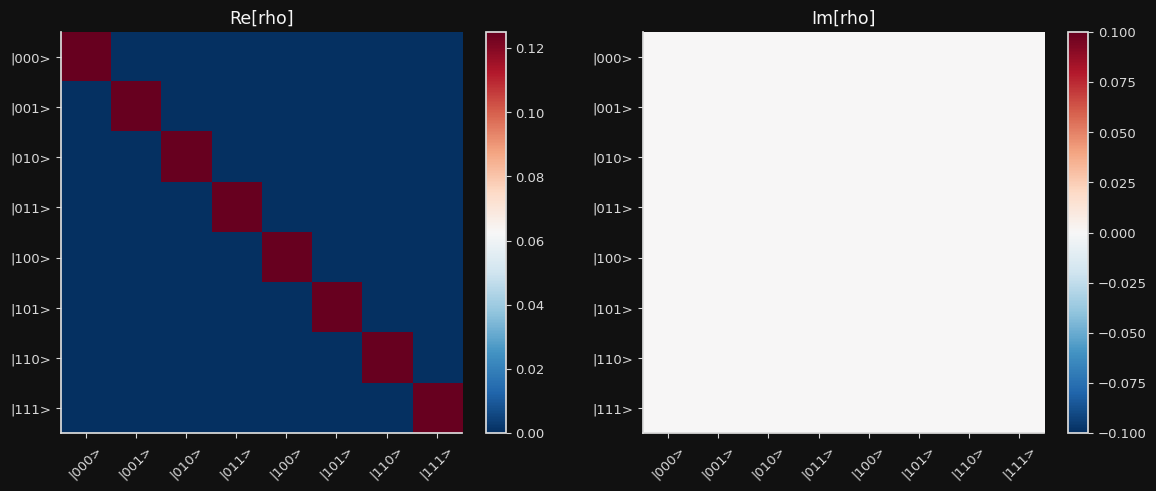

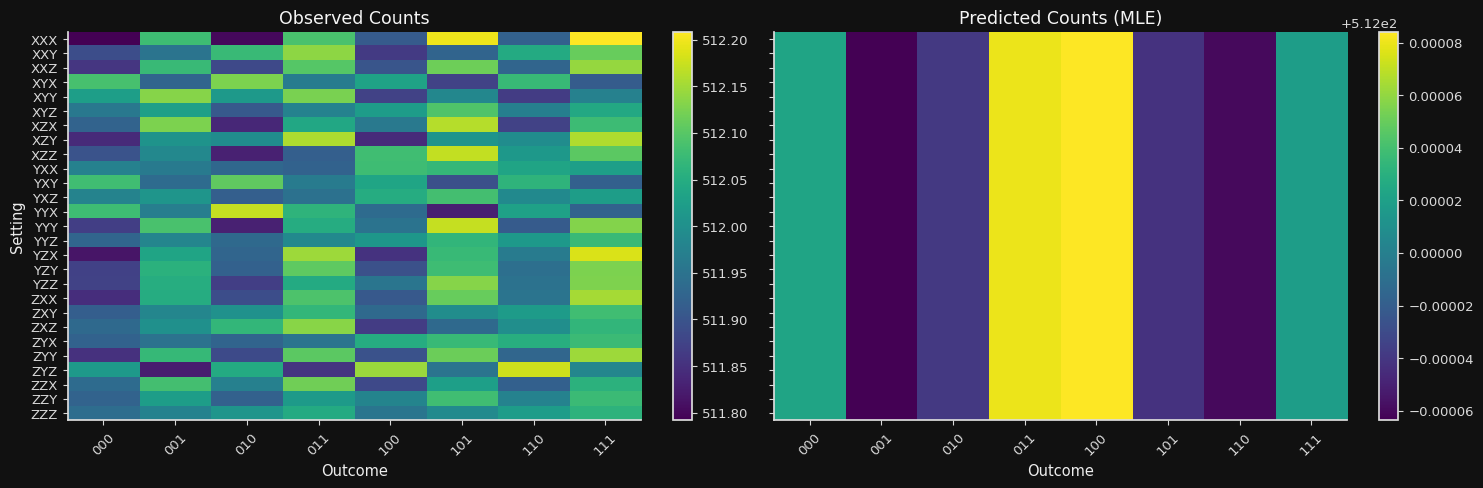

In [ ]:
from qubit_experiment.analysis import three_qubit_ghz as three_qubit_ghz_analysis
from qubit_experiment.experiments import three_qubit_ghz, three_qubit_readout_calibration
from qubit_experiment.qpu_types.bus_cavity import BusCavity
from qubit_experiment.qpu_types.bus_cavity.operations import BusCavityOperations
from qubit_experiment.qpu_types.fixed_transmon import FixedTransmonQubit
from qubit_experiment.qpu_types.fixed_transmon.operations import FixedTransmonOperations



# Ordered elements from the loaded parameter snapshot.
ghz_qubits = [qubits[0], qubits[1], qubits[2]]
ghz_bus = [buses[0], buses[1], buses[2]]

# Rebuild a runtime QPU from the current setup so the notebook does not rely
# on stale serialized wiring information.
runtime_qubits = FixedTransmonQubit.from_device_setup(
    setup,
    qubit_uids=[qubit.uid for qubit in ghz_qubits],
)
runtime_buses = BusCavity.from_device_setup(
    setup,
    qubit_uids=[bus.uid for bus in ghz_bus],
)
runtime_qubit_by_uid = {qubit.uid: qubit for qubit in runtime_qubits}
runtime_bus_by_uid = {bus.uid: bus for bus in runtime_buses}

# Reuse the latest saved calibration state through runtime-only overrides.
ghz_temporary_parameters = {}
for qubit in ghz_qubits:
    ghz_temporary_parameters[qubit.uid] = deepcopy(qubit.parameters)
for bus in ghz_bus:
    ghz_temporary_parameters[bus.uid] = deepcopy(bus.parameters)

for bus in ghz_bus:
    runtime_bus = runtime_bus_by_uid.get(bus.uid)
    if runtime_bus is None:
        raise RuntimeError(
            f"Bus {bus.uid!r} is missing from the current setup. "
            "Check the device descriptor and the setup bootstrap cell."
        )

    missing_signals = [line for line in ("drive", "drive_p") if line not in runtime_bus.signals]
    if missing_signals:
        missing_display = ", ".join(repr(line) for line in missing_signals)
        raise RuntimeError(
            f"Bus {bus.uid!r} is missing logical signal(s) {missing_display} in the current setup. "
            f"Add create_connection(to_signal=\"{bus.uid}/drive_p\", ...) as needed and refresh the GHZ-capable qpu_parameters snapshot."
        )

    effective_bus_parameters = ghz_temporary_parameters[bus.uid]
    missing_params = [
        field
        for field in (
            "resonance_frequency_bus",
            "drive_lo_frequency",
            "resonance_frequency_bus_p",
            "drive_p_lo_frequency",
        )
        if getattr(effective_bus_parameters, field, None) is None
    ]
    if missing_params:
        missing_display = ", ".join(missing_params)
        raise RuntimeError(
            f"Bus {bus.uid!r} is missing effective GHZ parameter(s): {missing_display}"
        )

ghz_runtime_qubits = [runtime_qubit_by_uid[qubit.uid] for qubit in ghz_qubits]
ghz_runtime_bus = [runtime_bus_by_uid[bus.uid] for bus in ghz_bus]
ghz_runtime_qpu = QPU(
    quantum_elements={"qubits": ghz_runtime_qubits, "bus": ghz_runtime_bus},
    quantum_operations=[FixedTransmonOperations, BusCavityOperations],
)

RUN_GHZ_CONVERGENCE_VALIDATION = False
GHZ_CONVERGENCE_REPEATS = 1
ghz_final_virtual_z_phases = (0.0, 0.0, 0.0)  # radians for (q0, q1, q2)

if "readout_cal_result_ghz" not in globals():
    print("readout_cal_result_ghz missing; running 3Q readout calibration once.")
    readout_cal_result_ghz = three_qubit_readout_calibration.experiment_workflow(
        session=session,
        qpu=ghz_runtime_qpu,
        qubits=ghz_runtime_qubits,
        temporary_parameters=ghz_temporary_parameters,
    ).run()
else:
    print("Reusing existing readout_cal_result_ghz.")

ghz_options = three_qubit_ghz.experiment_workflow.options()
ghz_options.do_analysis(True)
ghz_options.do_readout_calibration(False)
ghz_options.ghz_prep(True)
ghz_options.final_virtual_z_phases(ghz_final_virtual_z_phases)
ghz_options.do_convergence_validation(RUN_GHZ_CONVERGENCE_VALIDATION)
ghz_options.convergence_repeats(GHZ_CONVERGENCE_REPEATS)

ghz_analysis_options = three_qubit_ghz_analysis.analysis_workflow.options()
ghz_analysis_options.do_plotting(True)

ghz_output = three_qubit_ghz.run_bundle(
    session=session,
    qpu=ghz_runtime_qpu,
    qubits=ghz_runtime_qubits,
    bus=ghz_runtime_bus,
    readout_calibration_result=readout_cal_result_ghz,
    temporary_parameters=ghz_temporary_parameters,
    options=ghz_options,
    analysis_options=ghz_analysis_options,
)

ghz_analysis_output = ghz_output["analysis_result"]
ghz_convergence_report = ghz_output["convergence_report"]

fidelity_to_target = None
if isinstance(ghz_analysis_output, dict):
    metrics = ghz_analysis_output.get("metrics")
    if isinstance(metrics, dict):
        fidelity_to_target = metrics.get("fidelity_to_target")

print(f"Target state: {ghz_output['target_state_effective']}")
print(f"Fidelity to target: {fidelity_to_target}")
print(f"Convergence report produced: {ghz_convergence_report is not None}")


In [4]:
from copy import deepcopy

from laboneq.simple import Session, show_pulse_sheet
from laboneq_applications.tasks.parameter_updating import (
    temporary_qpu,
    temporary_quantum_elements_from_qpu,
)
from qubit_experiment.experiments import three_qubit_ghz
from qubit_experiment.experiments.three_qubit_ghz import ThreeQGhzExperimentOptions

if "session" not in globals() or session is None:
    session = Session(setup)
    session.connect(ignore_version_mismatch=False, do_emulation=False)

ghz_pulse_sheet_qubits = [qubits[0], qubits[1], qubits[2]]
ghz_pulse_sheet_bus = [buses[0], buses[1], buses[2]]

ghz_pulse_sheet_temporary_parameters = {}
for qubit in ghz_pulse_sheet_qubits:
    ghz_pulse_sheet_temporary_parameters[qubit.uid] = deepcopy(qubit.parameters)
for bus in ghz_pulse_sheet_bus:
    ghz_pulse_sheet_temporary_parameters[bus.uid] = deepcopy(bus.parameters)

ghz_pulse_sheet_qpu = temporary_qpu(qpu, ghz_pulse_sheet_temporary_parameters)
ghz_pulse_sheet_qubits = temporary_quantum_elements_from_qpu(
    ghz_pulse_sheet_qpu,
    ghz_pulse_sheet_qubits,
)
ghz_pulse_sheet_bus = temporary_quantum_elements_from_qpu(
    ghz_pulse_sheet_qpu,
    ghz_pulse_sheet_bus,
)

ghz_final_virtual_z_phases = (0.0, 0.0, 0.0)  # radians for (q0, q1, q2)

ghz_pulse_sheet_experiment = three_qubit_ghz.create_experiment(
    qpu=ghz_pulse_sheet_qpu,
    qubits=ghz_pulse_sheet_qubits,
    bus=ghz_pulse_sheet_bus,
    ghz_prep=True,
    final_virtual_z_phases=ghz_final_virtual_z_phases,
    options=ThreeQGhzExperimentOptions(count=1),
)
ghz_pulse_sheet_compiled_experiment = session.compile(ghz_pulse_sheet_experiment)

show_pulse_sheet(
    name="three_qubit_ghz",
    compiled_experiment=ghz_pulse_sheet_compiled_experiment,
    interactive=True,
    max_events_to_publish=20000,
)


[2026.03.12 08:02:16.140] INFO    Resolved modulation type of oscillator 'b0_drive_osc' on signal 'b0/drive' to HARDWARE
[2026.03.12 08:02:16.141] INFO    Resolved modulation type of oscillator 'b0_drive_p_osc' on signal 'b0/drive_p' to HARDWARE
[2026.03.12 08:02:16.141] INFO    Resolved modulation type of oscillator 'b1_drive_osc' on signal 'b1/drive' to HARDWARE
[2026.03.12 08:02:16.141] INFO    Resolved modulation type of oscillator 'b1_drive_p_osc' on signal 'b1/drive_p' to HARDWARE
[2026.03.12 08:02:16.141] INFO    Resolved modulation type of oscillator 'b2_drive_osc' on signal 'b2/drive' to HARDWARE
[2026.03.12 08:02:16.142] INFO    Resolved modulation type of oscillator 'b2_drive_p_osc' on signal 'b2/drive_p' to HARDWARE
[2026.03.12 08:02:16.142] INFO    Resolved modulation type of oscillator 'q0_readout_acquire_osc' on signal 'q0/acquire' to SOFTWARE
[2026.03.12 08:02:16.142] INFO    Resolved modulation type of oscillator 'q0_drive_ge_osc' on signal 'q0/drive' to HARDWARE
[2026